### 基于经典网络架构训练图像分类模型

**数据预处理部分：**

* 数据增强:torchvision中transforms模块自带功能
* 数据预处理:torchvision中transforms也帮我们实现好了,直接调用即可
* DataLoader模块直接读取batch数据

**网络模块设置:**

* 加载预训练模型, torchvision中有很多经典网络架构， 调用起来很方便， 并且可以使用别人的参数来继续训练， 也就是所谓的迁移学习
* 需要注意的是别人训练好的任务跟咱们不一样，需要把最后的head层改一下，一般也就是最后的全连接层，改成咱自己的任务
* 训练时可以全部重头训练，也可以只训练最后咱们任务的层，因为前几层都是做特征提取，本质任务目标一致


**模型网络保存与测试**

* 模型保存时可以有选择性
* 读取模型进行实际测试

In [105]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets,transforms,models
import numpy as np
import matplotlib.pyplot as plt
import imageio
import time
import warnings
import random
import sys
import copy
import json
from PIL import Image
import os


**数据读取与预处理操作**

In [106]:
data_dir = './dataset/flower_data'
train_dir = data_dir+'/train'
test_dir = data_dir+'/valid'

**制作好数据源**

* data_transforms中指定了所有图像预处理操作
* ImageFloder假设所有的文件保存好，每个文件下面存贮同一类别的图片， 文件夹的名字为分类的名字。

In [107]:
data_transforms = {
    'train':transforms.Compose([
        transforms.RandomRotation(45),#随机旋转, -45到45之间随机
        transforms.CenterCrop(224),#从中心开始裁剪
        transforms.RandomHorizontalFlip(p=0.5),#随机水平翻转,选择一个概率
        transforms.RandomVerticalFlip(p=0.5),#随机垂直旋转
        transforms.ColorJitter(brightness=0.2,contrast=0.1,saturation=0.1,hue=0.1), # 参数1为亮度,参数2为对比度,参数3为饱和度,参数4为色相
        transforms.RandomGrayscale(p=0.025),#概率转化成灰度率，3通道就是R=G=B
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])#均值, #标准差
    ]),
    'valid':transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])#均值, #标准差
    ])
}

In [108]:
batch_size = 8

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir,x), data_transforms[x]) for x in ['train', 'valid']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x],batch_size = batch_size, shuffle=True) for x in ['train', 'valid']}
dataset_sizes = {x:len(image_datasets[x]) for x in ['train','valid']}
class_names = image_datasets['train'].classes

In [109]:
image_datasets

{'train': Dataset ImageFolder
     Number of datapoints: 6552
     Root location: ./dataset/flower_data\train
     StandardTransform
 Transform: Compose(
                RandomRotation(degrees=[-45.0, 45.0], interpolation=nearest, expand=False, fill=0)
                CenterCrop(size=(224, 224))
                RandomHorizontalFlip(p=0.5)
                RandomVerticalFlip(p=0.5)
                ColorJitter(brightness=[0.8, 1.2], contrast=[0.9, 1.1], saturation=[0.9, 1.1], hue=[-0.1, 0.1])
                RandomGrayscale(p=0.025)
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ),
 'valid': Dataset ImageFolder
     Number of datapoints: 818
     Root location: ./dataset/flower_data\valid
     StandardTransform
 Transform: Compose(
                Resize(size=256, interpolation=bilinear, max_size=None, antialias=None)
                CenterCrop(size=(224, 224))
                ToTensor()
                Normalize(mea

In [110]:
dataloaders

{'train': <torch.utils.data.dataloader.DataLoader at 0x1c8a7dbc308>,
 'valid': <torch.utils.data.dataloader.DataLoader at 0x1c8d85d3b88>}

In [111]:
dataset_sizes

{'train': 6552, 'valid': 818}

In [147]:
with open ('./dataset/flower_data/cat_to_name.json','r') as f:
    cat_to_name = json.load(f)

In [148]:
cat_to_name

{'21': 'fire lily',
 '3': 'canterbury bells',
 '45': 'bolero deep blue',
 '1': 'pink primrose',
 '34': 'mexican aster',
 '27': 'prince of wales feathers',
 '7': 'moon orchid',
 '16': 'globe-flower',
 '25': 'grape hyacinth',
 '26': 'corn poppy',
 '79': 'toad lily',
 '39': 'siam tulip',
 '24': 'red ginger',
 '67': 'spring crocus',
 '35': 'alpine sea holly',
 '32': 'garden phlox',
 '10': 'globe thistle',
 '6': 'tiger lily',
 '93': 'ball moss',
 '33': 'love in the mist',
 '9': 'monkshood',
 '102': 'blackberry lily',
 '14': 'spear thistle',
 '19': 'balloon flower',
 '100': 'blanket flower',
 '13': 'king protea',
 '49': 'oxeye daisy',
 '15': 'yellow iris',
 '61': 'cautleya spicata',
 '31': 'carnation',
 '64': 'silverbush',
 '68': 'bearded iris',
 '63': 'black-eyed susan',
 '69': 'windflower',
 '62': 'japanese anemone',
 '20': 'giant white arum lily',
 '38': 'great masterwort',
 '4': 'sweet pea',
 '86': 'tree mallow',
 '101': 'trumpet creeper',
 '42': 'daffodil',
 '22': 'pincushion flower',
 

**展示下数据**
* 注意tensor的数据需要转换成numpy格式，而且还需要还原回标准化的结果

In [114]:


def im_convert(tensor):
    """将张量转换为图像格式"""
    image = tensor.cpu().clone().detach()  # 克隆张量，并确保在 CPU 上进行处理
    image = image.numpy().squeeze()  # 转换为 NumPy 数组
    image = image.transpose(1, 2, 0)  # 交换维度以得到 HxWxC 的格式
    image = image * np.array((0.229, 0.224, 0.225)) + np.array((0.485, 0.456, 0.406))  # 去归一化
    image = np.clip(image, 0, 1)  # 将值裁剪到 [0, 1] 的范围
    
    return image


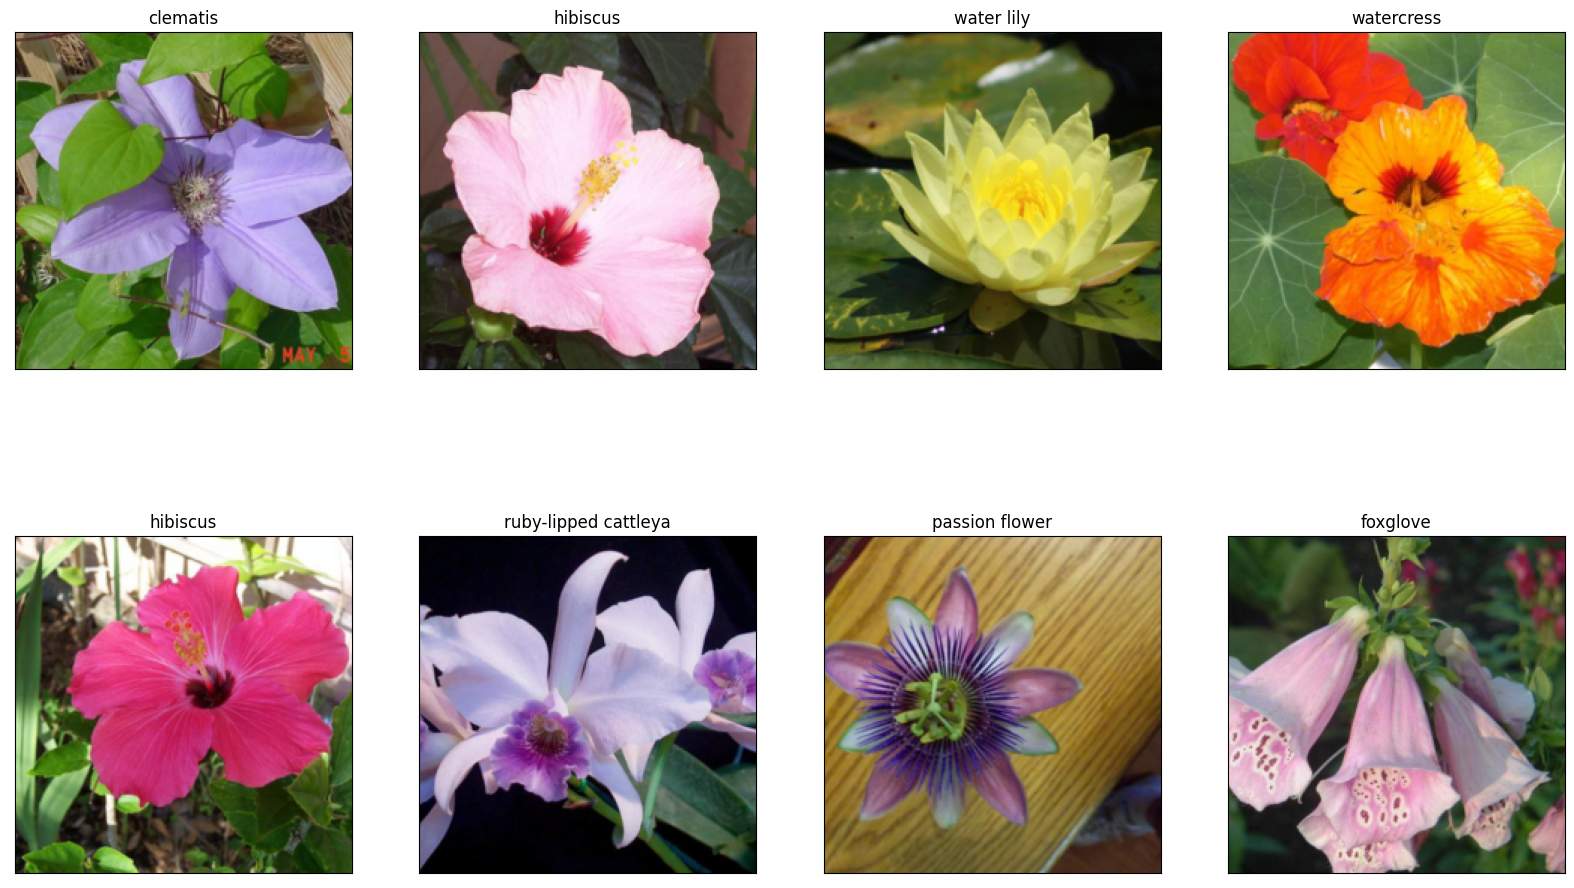

In [115]:
fig = plt.figure(figsize=(20,12))
columns  = 4
rows = 2

dataiter = iter(dataloaders['valid'])
inputs, classes = next(dataiter)

for idx in range(columns*rows):
    ax = fig.add_subplot(rows, columns, idx+1, xticks = [], yticks = [])
    ax.set_title(cat_to_name[str(int(class_names[classes[idx]]))])
    plt.imshow(im_convert(inputs[idx]))

plt.show()

**加载model中给的模型，并且直接用训练好的权重作为初始化参数**

In [116]:
model_name = 'resnet' #['resnet', 'alexnet', 'vgg', 'squeezenet', 'densenet', 'inception']

feature_extract = True #是否使用人家的特征提取

In [117]:
train_on_GPU = torch.cuda.is_available()

if not train_on_GPU:
    print('CUDA is not available. Training on CPU...')
else:
    print('CUDA is available. Training on GPU...')

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


CUDA is available. Training on GPU...


In [118]:
def set_parameter_requires_grad(model, feature_extracting):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False
            

In [119]:
model_ft = models.resnet152()
model_ft

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

**Pytorch官网例子**

In [120]:
def initialize_model(model_name, num_classes, feature_extract, use_pretrained=True):
    # 初始化要返回的模型、输入尺寸和是否需要特征提取
    model_ft = None
    input_size = 0

    if model_name == "resnet":
        """ Resnet152 """
        model_ft = models.resnet152(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.fc.in_features
        model_ft.fc = nn.Sequential(nn.Linear(num_ftrs, 102),
                                    nn.LogSoftmax(dim=1)
                                    )
        input_size = 224

    elif model_name == "alexnet":
        """ Alexnet """
        model_ft = models.alexnet(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.classifier[6].in_features
        model_ft.classifier[6] = nn.Linear(num_ftrs, num_classes)
        input_size = 224

    elif model_name == "vgg":
        """ VGG11_bn """
        model_ft = models.vgg11_bn(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.classifier[6].in_features
        model_ft.classifier[6] = nn.Linear(num_ftrs, num_classes)
        input_size = 224

    elif model_name == "squeezenet":
        """ Squeezenet """
        model_ft = models.squeezenet1_0(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        model_ft.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=(1,1), stride=(1,1))
        model_ft.num_classes = num_classes
        input_size = 224

    elif model_name == "densenet":
        """ Densenet """
        model_ft = models.densenet121(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.classifier.in_features
        model_ft.classifier = nn.Linear(num_ftrs, num_classes)
        input_size = 224

    elif model_name == "inception":
        """ Inception v3 """
        model_ft = models.inception_v3(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        # Handle the auxiliary net
        num_ftrs = model_ft.AuxLogits.fc.in_features
        model_ft.AuxLogits.fc = nn.Linear(num_ftrs, num_classes)
        # Handle the primary net
        num_ftrs = model_ft.fc.in_features
        model_ft.fc = nn.Linear(num_ftrs, num_classes)
        input_size = 299

    else:
        print("Invalid model name, exiting...")
        exit()

    return model_ft, input_size

In [121]:
model_ft, input_size = initialize_model(model_name, 102, feature_extract, use_pretrained=True)

# GPU
model_ft = model_ft.to(device)

# 模型保存
filename = 'checkpoint.pth'

# 是否训练所有层
params_to_update = model_ft.parameters()

print("Params to learn:")
if feature_extract:
    params_to_update = []
    for name, param in model_ft.named_parameters():  # 使用 named_parameters() 方法
        if param.requires_grad == True:
            params_to_update.append(param)
            print("\t", name)
else:
    for name, param in model_ft.named_parameters():  # 使用 named_parameters() 方法
        if param.requires_grad == True:
            print("\t", name)


Params to learn:
	 fc.0.weight
	 fc.0.bias


In [122]:
model_ft

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

**优化器设置**

In [123]:
optimizer_ft = optim.Adam(params_to_update, lr = 1e-2 )

scheduler = optim.lr_scheduler.StepLR(optimizer_ft,step_size=7, gamma=0.1) # 学习率每7个epoch衰减为原来的1/10
# 最后一层已经LogSoftmax()了,所以不能nn.CrossEntropyLoss()来计算了, nn.CrossEntropyLoss()相当于nn.LogSoftmax()和nn.NLLLoss整合
criterion = nn.NLLLoss()


**训练模块**

In [124]:
def train_model(model, dataloaders, criterion, optimizer_ft, scheduler, num_epochs=25, is_inception=False, filename='checkpoint.pth'):
    since = time.time()
    best_acc = 0

    model.to(device)

    val_acc_history = []
    train_acc_history = []
    valid_losses = []
    train_losses = []
    test_losses = []
    LRs = [optimizer_ft.param_groups[0]['lr']]

    best_model_wts = copy.deepcopy(model.state_dict()) #最好模型权重文件

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs-1))
        print('-'*10)

        #训练和验证
        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train() # 训练
            else:
                model.eval() # 验证

            running_loss = 0.0
            running_corrects = 0.0

            # 把数据都取个遍
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                # 梯度清零
                optimizer_ft.zero_grad()
                # 只有训练的时候计算和更新梯度
                with torch.set_grad_enabled(phase == 'train'):
                    if is_inception and phase == 'train':
                        outputs, aux_outputs = model(inputs)
                        loss1 = criterion(outputs, labels)
                        loss2 = criterion(aux_outputs, labels)
                        loss = loss1 + 0.4*loss2
                    else: # resnet是执行这里
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    #训练阶段更新权重
                    if phase == 'train':
                        loss.backward()
                        optimizer_ft.step()

                #计算损失
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            #得到最好那次的模型
            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                state = {
                    'state_dict': model.state_dict(),
                    'best_acc': best_acc,
                    'optimizer': optimizer_ft.state_dict(),
                    'scheduler': scheduler.state_dict(),
                    'epoch': epoch
                }
                torch.save(state, filename)
            if phase == 'valid':
                val_acc_history.append(epoch_acc)
                valid_losses.append(epoch_loss)
                scheduler.step(epoch_loss)
            if phase == 'train':
                train_acc_history.append(epoch_acc)
                train_losses.append(epoch_loss)

        print('OPtimizer learning rate: {:.7f}'.format(optimizer_ft.param_groups[0]['lr']))
        LRs.append(optimizer_ft.param_groups[0]['lr'])
        print()

    time_elapse = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapse//60, time_elapse%60))
    print('Best val Acc: {:4f}'.format(best_acc))

    #训练完后用最好的一次当训练的最终结果
    model.load_state_dict(best_model_wts)
    return model, val_acc_history, train_acc_history, valid_losses, train_losses, LRs


In [104]:
model_ft, val_acc_history, train_acc_history, valid_losses, train_losses, LRs = train_model(
    model_ft, 
    dataloaders, 
    criterion, 
    optimizer_ft, 
    scheduler,  # <- 确保传递 scheduler 参数
    num_epochs=20,
    is_inception=False,
    filename=filename
)

Epoch 0/19
----------
train Loss: 10.1493 Acc: 0.3223
valid Loss: 12.8607 Acc: 0.3802
OPtimizer learning rate: 0.0010000

Epoch 1/19
----------
train Loss: 2.3173 Acc: 0.7001
valid Loss: 3.9556 Acc: 0.6051
OPtimizer learning rate: 0.0100000

Epoch 2/19
----------
train Loss: 9.6931 Acc: 0.4754
valid Loss: 10.8923 Acc: 0.4976
OPtimizer learning rate: 0.0010000

Epoch 3/19
----------
train Loss: 2.8465 Acc: 0.7384
valid Loss: 5.7247 Acc: 0.6333
OPtimizer learning rate: 0.0100000

Epoch 4/19
----------
train Loss: 9.1538 Acc: 0.5548
valid Loss: 13.9342 Acc: 0.5257
OPtimizer learning rate: 0.0010000

Epoch 5/19
----------
train Loss: 2.9826 Acc: 0.7636
valid Loss: 5.1472 Acc: 0.6980
OPtimizer learning rate: 0.0100000

Epoch 6/19
----------
train Loss: 9.1548 Acc: 0.5873
valid Loss: 18.5153 Acc: 0.4841
OPtimizer learning rate: 0.0001000

Epoch 7/19
----------
train Loss: 5.8760 Acc: 0.6967
valid Loss: 10.2984 Acc: 0.6406
OPtimizer learning rate: 0.0010000

Epoch 8/19
----------
train Loss: 

**再训练所有层**

In [125]:
for param in model_ft.parameters():#设置所有参数都需要进行训练
    param.requires_grad = True

# 在训练所有参数，学习率调小一些
optimizer = optim.Adam(params_to_update, lr= 1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

#损失函数
criterion = nn.NLLLoss()

In [126]:

checkpoint = torch.load(filename)
best_acc = checkpoint['best_acc']
model_ft.load_state_dict(checkpoint['state_dict'])
optimizer.load_state_dict(checkpoint['optimizer'])

In [127]:
model_ft, val_acc_history, train_acc_history, valid_losses, train_losses, LRs = train_model(model_ft, dataloaders, criterion, optimizer,scheduler,num_epochs=10,is_inception=False,filename=filename)

Epoch 0/9
----------
train Loss: 2.7477 Acc: 0.8277
valid Loss: 8.2617 Acc: 0.6919
OPtimizer learning rate: 0.0010000

Epoch 1/9
----------
train Loss: 2.7267 Acc: 0.8283
valid Loss: 6.9184 Acc: 0.7445
OPtimizer learning rate: 0.0010000

Epoch 2/9
----------
train Loss: 2.6298 Acc: 0.8335
valid Loss: 7.0522 Acc: 0.7115
OPtimizer learning rate: 0.0010000

Epoch 3/9
----------
train Loss: 2.6362 Acc: 0.8341
valid Loss: 6.8889 Acc: 0.7274
OPtimizer learning rate: 0.0010000

Epoch 4/9
----------
train Loss: 2.5355 Acc: 0.8368
valid Loss: 7.1828 Acc: 0.7115
OPtimizer learning rate: 0.0010000

Epoch 5/9
----------
train Loss: 2.5641 Acc: 0.8356
valid Loss: 8.3228 Acc: 0.6932
OPtimizer learning rate: 0.0010000

Epoch 6/9
----------
train Loss: 2.3653 Acc: 0.8384
valid Loss: 6.9879 Acc: 0.7335
OPtimizer learning rate: 0.0010000

Epoch 7/9
----------
train Loss: 2.5759 Acc: 0.8335
valid Loss: 6.4900 Acc: 0.7323
OPtimizer learning rate: 0.0010000

Epoch 8/9
----------
train Loss: 2.4350 Acc: 0.8

**加载训练好的模型**

In [128]:
model_ft, input_size = initialize_model(model_name, 102, feature_extract, use_pretrained=True)

#GPU
model_ft = model_ft.to(device)

filename = 'checkpoint.pth'

#加载模型
checkpoint = torch.load(filename)
best_acc = checkpoint['best_acc']
model_ft.load_state_dict(checkpoint['state_dict'])

d:\Anconda\envs\Paddle_tutorial\lib\site-packages\torchvision\models\_utils.py:209: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  f"The parameter '{pretrained_param}' is deprecated since 0.13 and may be removed in the future, "
d:\Anconda\envs\Paddle_tutorial\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet152_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet152_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


<All keys matched successfully>

**测试数据预处理**
* 测试数据处理方法需要跟训练时一样
* crop操作的目的是保证输入的大小是一致的
* 标准化操作也是必须的，用跟训练数据相同的mean和std，但是需要注意一点训练数据是在0-1上进行标准化，所以测试数据也需要先归一化
* 最后一点，Pytorch中颜色通道是第一个维度，许多工具包与之不同，需要转换


In [137]:
def process_image(image_path):
    #读取测试数据
    img = Image.open(image_path)
    if img.size[0]> img.size[1]:
        img.thumbnail((10000, 256))
    else:
        img.thumbnail((256, 10000))

    #Crop操作
    left_margin = (img.width-224)/2
    bottom_margin = (img.height-224)/2
    right_margin = left_margin+ 224
    top_margin = bottom_margin + 224
    img = img.crop((left_margin, bottom_margin, right_margin, top_margin))

    #相同预处理办法
    img = np.array(img)/255
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = (img - mean)/std

    img = img.transpose((2, 0, 1))

    return img 

In [139]:
def imshow(image, ax = None, title= None):
    if ax is None:
        fig, ax = plt.subplots()

    #颜色通道还原
    image = np.array(image).transpose((1,2,0))

    #预处理还原
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image = std * image + mean
    image = np.clip(image, 0, 1)

    ax.imshow(image)
    ax.set_title(title)

    return ax

<AxesSubplot:>

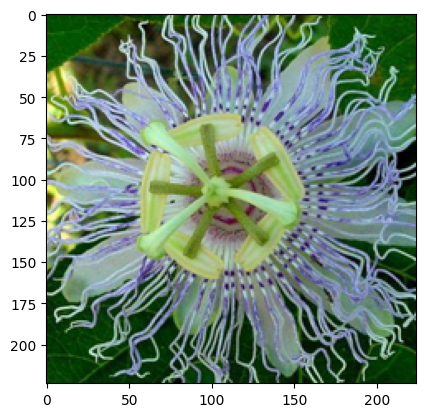

In [140]:
image_path = './dataset/flower_data/test/image_00025.jpg'

img = process_image(image_path)

imshow(img)

In [141]:
img.shape

(3, 224, 224)

In [143]:
# 得到一个batch的测试数据

dataiter = iter(dataloaders['valid'])
images, labels = next(dataiter)

model_ft.eval()

if train_on_GPU:
    output = model_ft(images.cuda())
else:
    output = model_ft(images)

output表示对一个batch中每一个数据得到其属于各个类别的可能性

In [144]:
output.shape

torch.Size([8, 102])

**得到概率最大的那个**

In [145]:
_, preds_tensor = torch.max(output, 1)

preds = np.squeeze(preds_tensor.numpy()) if not train_on_GPU else np.squeeze(preds_tensor.cpu().numpy())

preds

array([51, 88, 43,  0, 15, 85, 73,  0], dtype=int64)

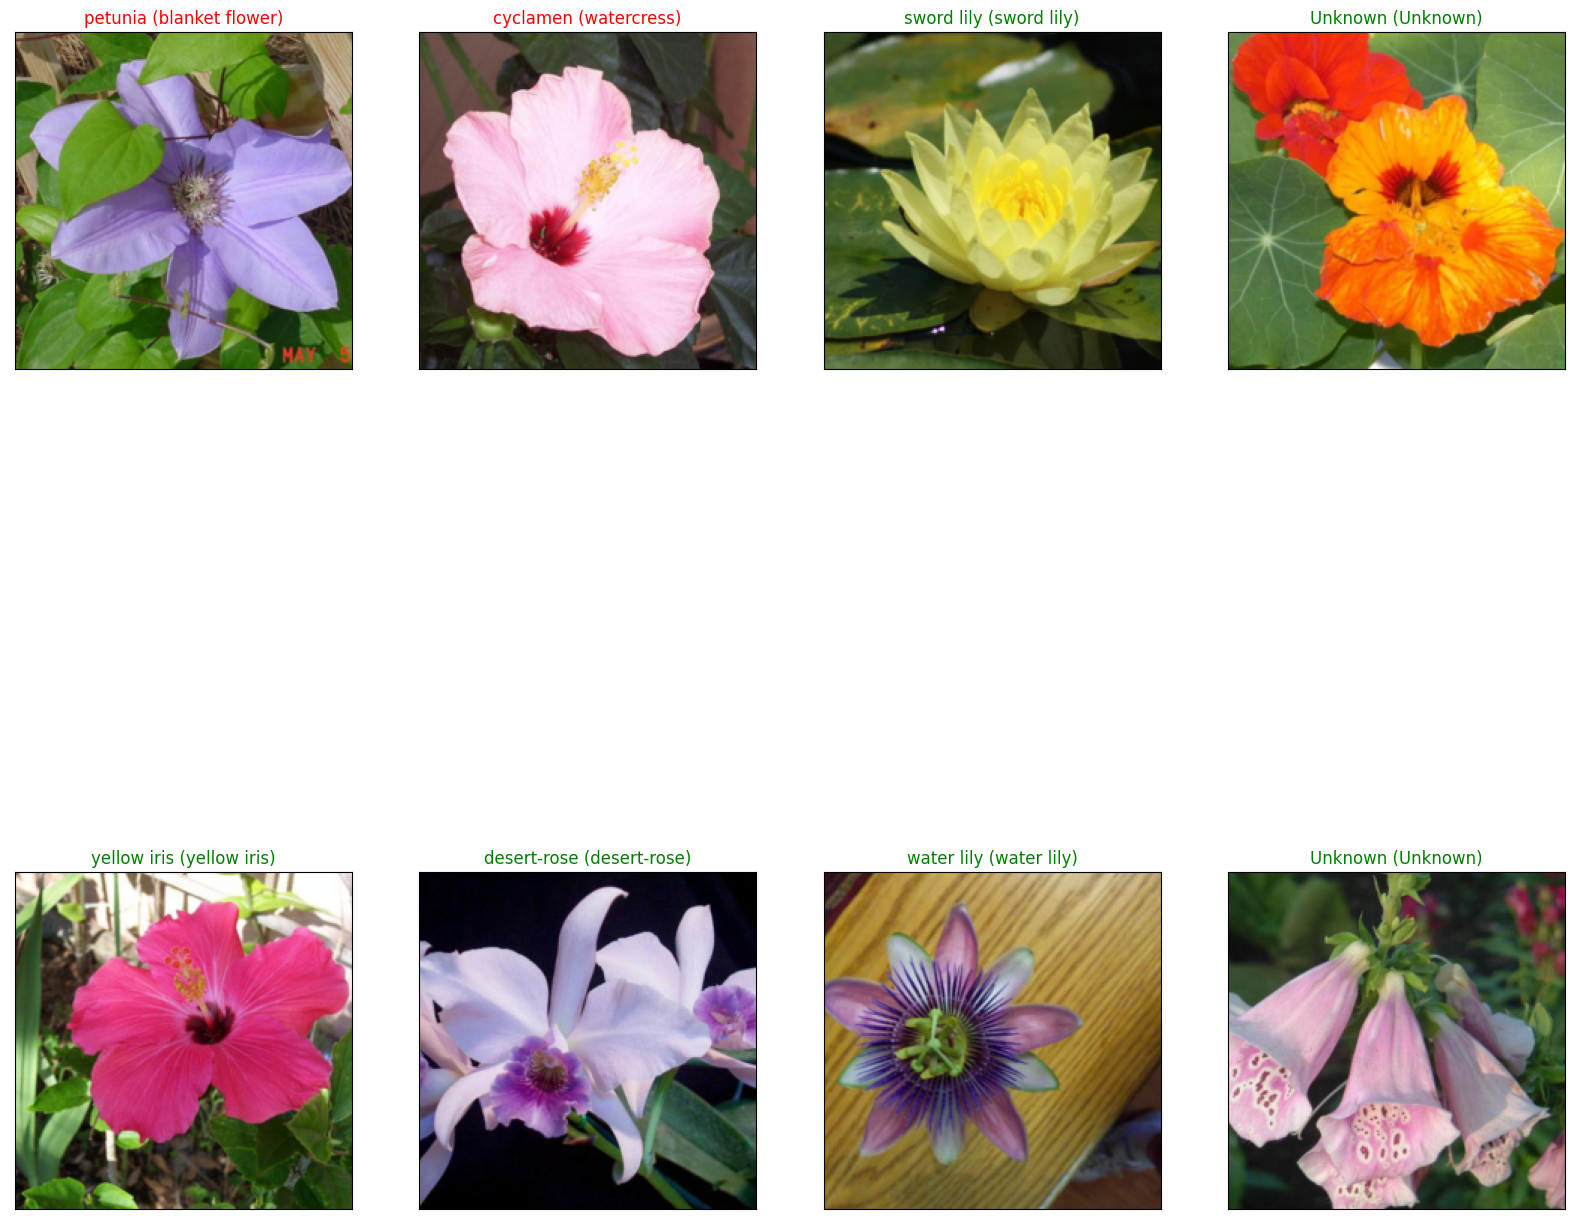

In [150]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(20, 20))
columns = 4
rows = 2

for idx in range(columns * rows):
    ax = fig.add_subplot(rows, columns, idx + 1, xticks=[], yticks=[])

    # 显示图像
    ax.imshow(im_convert(inputs[idx]))

    # 获取预测和标签
    pred_label = str(preds[idx])
    true_label = str(labels[idx].item())
    
    # 获取名称
    pred_name = cat_to_name.get(pred_label, "Unknown")
    true_name = cat_to_name.get(true_label, "Unknown")

    # 设置标题
    ax.set_title(f"{pred_name} ({true_name})", 
                 color="green" if pred_name == true_name else "red")

plt.show()
